# PBMC (Peripheral Blood Mononuclear Cells) 3k dataset analysis

In [1]:
import pandas as pd
import scanpy as sc

### Load dataset

In [2]:
results_file = 'pbmc3k.h5ad'

In [3]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

### See what is inside

Here is what adata (Annotated data) object contains:

adata <br>
├── X      --- expression matrix (cells × genes) <br>
├── obs    --- cell metadata (e.g., clusters, QC) <br>
├── var    --- gene metadata (e.g., gene names, types) <br>
├── obsm   --- multi-dimensional embeddings (UMAP, PCA) <br>
├── layers --- optional layers (normalized counts, log counts) <br>
└── uns    --- unstructured info (colors, marker gene lists)

Adata.X contains sparse matrix for 2700 cells (their indexes) and 32738 genes expression levels in these cells

In [4]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [5]:
adata.X

<2700x32738 sparse matrix of type '<class 'numpy.float32'>'
	with 2286884 stored elements in Compressed Sparse Row format>

In [6]:
adata.to_df()

index,MIR1302-10,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,AL627309.1,RP11-34P13.14,RP11-34P13.9,AP006222.2,RP4-669L17.10,...,KIR3DL2-1,AL590523.1,CT476828.1,PNRC2-1,SRSF10-1,AC145205.1,BAGE5,CU459201.1,AC002321.2,AC002321.1
index,,,,,,,,,,,,,,,,,,,,,
AAACATACAACCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTGAGGCA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTTCCTCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Cell indexes are stored in adata.obs and genes with their Ensembl genome database IDs are stored in adata.var

In [7]:
adata.obs.head() # cell metadata

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [8]:
adata.obs_names

Index(['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1',
       'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1', 'AAACGCACTGGTAC-1',
       'AAACGCTGACCAGT-1', 'AAACGCTGGTTCTT-1', 'AAACGCTGTAGCCA-1',
       'AAACGCTGTTTCTG-1',
       ...
       'TTTCAGTGTCACGA-1', 'TTTCAGTGTCTATC-1', 'TTTCAGTGTGCAGT-1',
       'TTTCCAGAGGTGAG-1', 'TTTCGAACACCTGA-1', 'TTTCGAACTCTCAT-1',
       'TTTCTACTGAGGCA-1', 'TTTCTACTTCCTCG-1', 'TTTGCATGAGAGGC-1',
       'TTTGCATGCCTCAC-1'],
      dtype='object', name='index', length=2700)

In [9]:
adata.var.head() # gene metadata

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


In [10]:
adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='object', name='index', length=32738)

These seems to be empty

In [11]:
adata.obsm.keys()

KeysView(AxisArrays with keys: )

In [12]:
adata.layers

Layers with keys: 

In [13]:
adata.uns

OrderedDict()

### Preprocessing and QC

See what the highest expression genes (surprise-purprise (of course, not) there is bunch of ribosomal proteins, long non-coding RNA and actin)

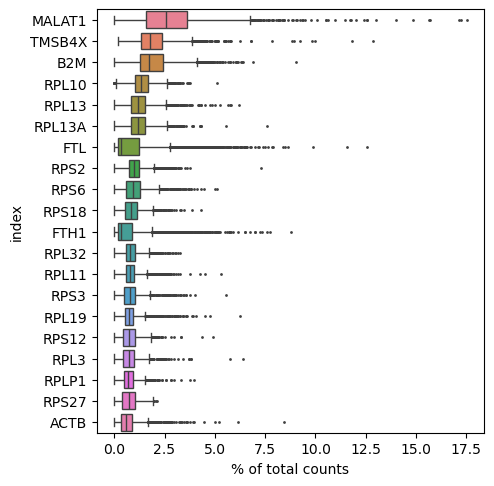

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [14]:
sc.pl.highest_expr_genes(adata, n_top=20, )
adata

Let's filter out cells with too little genes detected (dead cells or empty droplets) and genes that were detected in too little cells (probably noise). 

In [15]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# Added columns: 
    #'n_genes' - how many genes are expressed in that cell 
    #'n_cells' - for how many cells particular gene is expressed 
    
adata

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'

In [16]:
adata.obs.head()

,n_genes
index,
AAACATACAACCAC-1,781
AAACATTGAGCTAC-1,1352
AAACATTGATCAGC-1,1131
AAACCGTGCTTCCG-1,960
AAACCGTGTATGCG-1,522


In [17]:
adata.var.head()

,gene_ids,n_cells
index,,
AL627309.1,ENSG00000237683,9
AP006222.2,ENSG00000228463,3
RP11-206L10.2,ENSG00000228327,5
RP11-206L10.9,ENSG00000237491,3
LINC00115,ENSG00000225880,18


Quality control (high proportion of mitochondrial cells -> stressed/dying cells)

Add column with boolean values to find which genes are mitochondrial <br>
pp = preprocessing module <br>

Let's calculate percentage of counts coming from mitochondrial genes for each cell

In [18]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# Added columns: 
    # for obs - 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    # for var -  'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
adata

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

Let's visualize:

* n_genes_by_counts - number of genes detected in a cell (we already removed values under 200, whatever is an outlier high - probably doublet of cells). 
* total_counts - total RNA counts in a cell (too low - > poor quality, too high -> also doublets or highly metabolically active cells)
* pct_counts_mt - percentage of RNA coming from mitochondrial genes (5% - normal, 5-10% borderline, >10% stressed/dying)

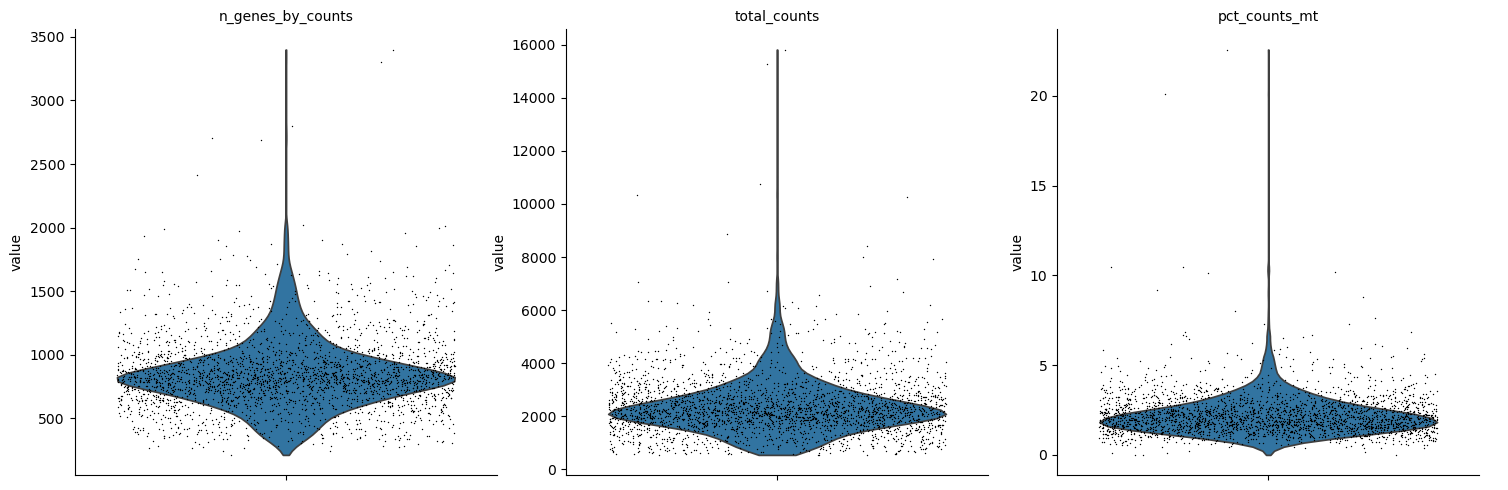

In [19]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

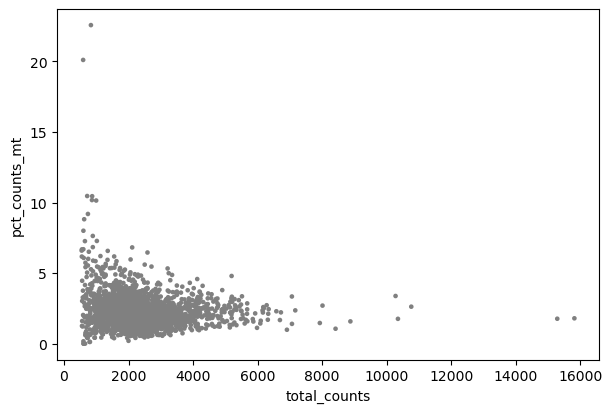

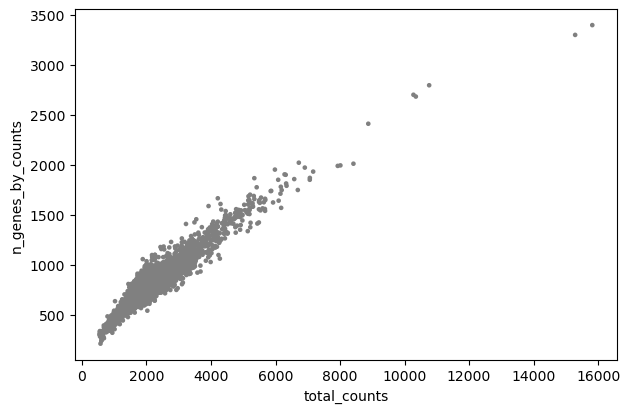

In [20]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

Now we filter out cells where mitochondrial fraction is over 5% and total genes detected over 2500 (removed 62 cells only). These could be potential doublets. Total gene number of 2500 is concluded from the graphs by eye, however there are tools such as <b> Scrublet (Python) and DoubletFinder (R).  

In [21]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
adata

View of AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

Library-size normalization (counts for each cell are normalized in a way so that if it had 10,000 reads per cell). Makes counts  comparable among cells (before that some cells are deeper or shallower sequenced). 

Formula: 
normalized counts = original counts/total counts in the cell X 10,000

In [22]:
sc.pp.normalize_total(adata, target_sum=1e4)

C:\Users\volko\anaconda3\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Logarithmize the data to prevent the downstream analysis being dominated by genes with very high counts and of course to avoid log(0):

log(1 + normalized counts)

In [23]:
sc.pp.log1p(adata)

### Identify highly-variable genes

These genes are actually distinguishing cell types.

This will calculate mean expression and cut off genes that are barely expressed anywhere and genes that are expressed everywhere. And it keeps genes with expression varying more then expected.

Columns:
* highly_variable - Boolean mask: which genes are selected
* means, dispersions, dispersions_norm

In [24]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

In [25]:
adata.var[ [ 'highly_variable', 'means', 'dispersions', 'dispersions_norm' ]].head()

,highly_variable,means,dispersions,dispersions_norm
index,,,,
AL627309.1,False,0.013556,1.432845,-0.624328
AP006222.2,False,0.004696,1.458631,-0.573415
RP11-206L10.2,False,0.005673,1.325459,-0.836358
RP11-206L10.9,False,0.002644,0.859264,-1.756848
LINC00115,False,0.027437,1.457477,-0.575693


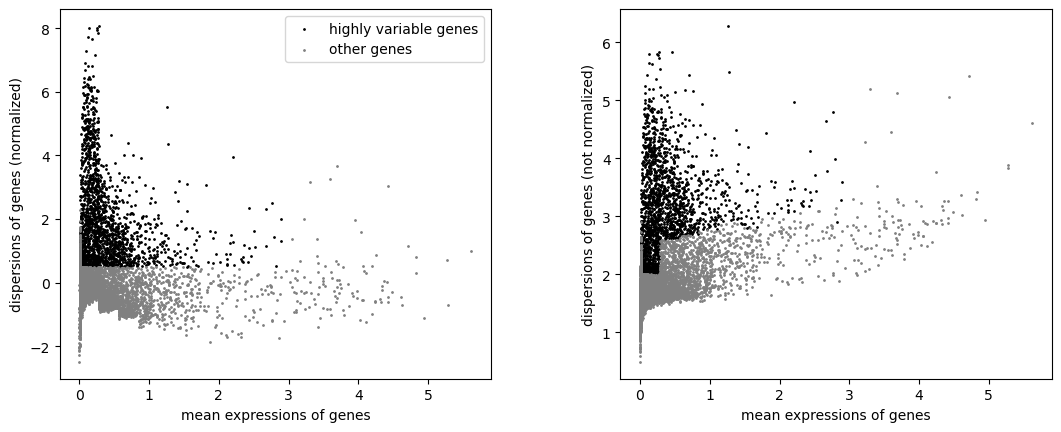

In [26]:
sc.pl.highly_variable_genes(adata)

Befor selecting only higly variable genes and scaling the data, we freez current state of dataset in .raw

In [27]:
adata.raw = adata

Now we keep in adata only highly variable genes.

In [28]:
adata = adata[:, adata.var.highly_variable]
adata

View of AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

Regress out will help to substrct the noise component from the data and see biological difference more clear. However, be aware that sometimes regressing out could be harmful as it can remove real biology - for instance activated or larger cells often have more RNA, or if you are looking for cells under stress they may actually have higher mitochondrial RNA for a reason, when doing differential expression you need log-normalized data.

Values substitutes with residuals (what is left after you remove variance explaind by sequencing depth and mt content).

In [29]:
not_regressed_data = adata.copy()

In [30]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

C:\Users\volko\anaconda3\lib\site-packages\scanpy\preprocessing\_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Now we do z-score scaling per gene (mean - 0, standard deviation - 1), also any values higher then 10 or lower then -10 are substituted for 10 and -10.

In [31]:
sc.pp.scale(adata, max_value=10)

In [32]:
sc.pp.scale(not_regressed_data, max_value=10)

## PCA

In [33]:
sc.tl.pca(adata, svd_solver='arpack')

# Adds: adata.obsm.X_pca, adata.varm.PCs

In [34]:
sc.tl.pca(not_regressed_data, svd_solver='arpack')

In [35]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

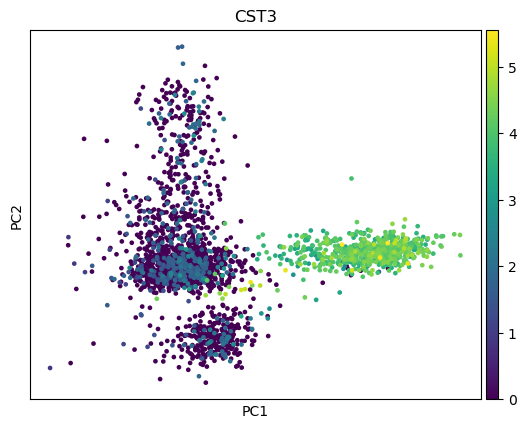

In [36]:
sc.pl.pca(adata, color='CST3')

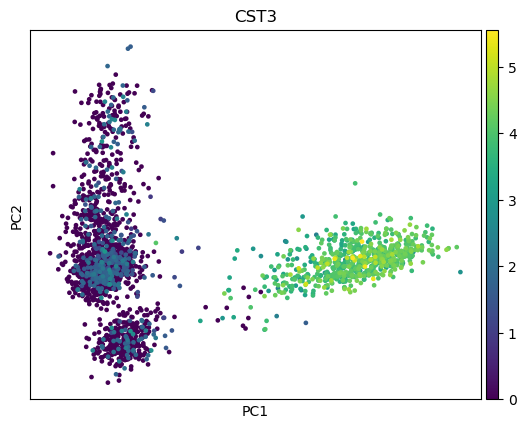

In [37]:
sc.pl.pca(not_regressed_data, color='CST3')

To me looks like regressing out did not change PCA plot much so I feel it can be omitted for this dataset.

Let's see how many principal components are contributing the most and choose how many of them to use for following analysis.

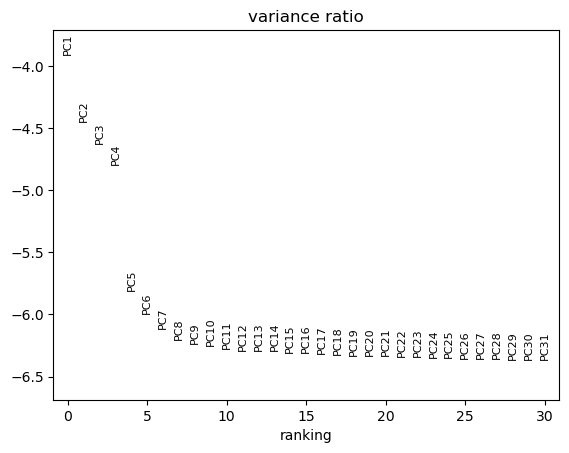

In [38]:
sc.pl.pca_variance_ratio(adata, log=True)

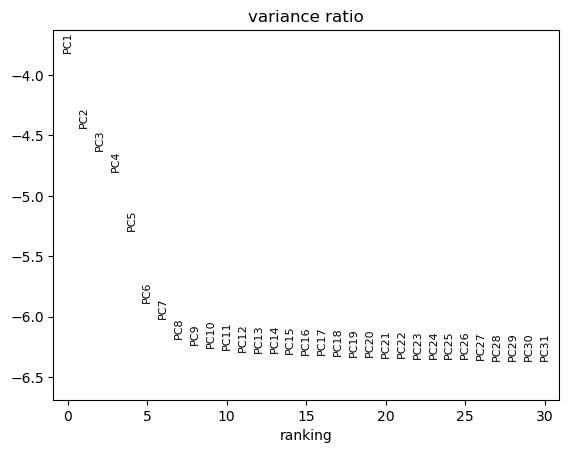

In [39]:
sc.pl.pca_variance_ratio(not_regressed_data, log=True)

Save the result.

In [40]:
adata.write("results_file")

## Computing the neighborhood graph

Let us compute the neighborhood graph of cells using the PCA representation of the data matrix. You might simply use default values here. For the sake of reproducing Seurat’s results, let’s take the following values.

In [41]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

## Embedding the neighborhood graph

Embedding in that case is putting it into 2D.

Note - UMAP embedding:
- is not the raw data
- is not quantitative distance
- It’s a visual representation

We suggest embedding the graph in two dimensions using UMAP (McInnes et al., 2018), see below. It is potentially more faithful to the global connectivity of the manifold than tSNE, i.e., it better preserves trajectories. In some ocassions, you might still observe disconnected clusters and similar connectivity violations. They can usually be remedied by running:

sc.tl.paga(adata) sc.pl.paga(adata, plot=False) # remove plot=False if you want to see the coarse-grained graph sc.tl.umap(adata, init_pos='paga')

In [42]:
sc.tl.umap(adata)

In the PBMC3k dataset:
- CST3 → monocytes
- NKG7 → NK / cytotoxic T cells
- PPBP → platelets
These are marker genes

For a new dataset in Scanpy:
- Cluster the cells
- Find marker genes per cluster
- Use those genes to identify cell types
- Plot those genes (UMAP coloring)

Example:
- CD3D, CD3E → T cells
- MS4A1 → B cells
- NKG7 → NK cells
- LYZ → monocytes

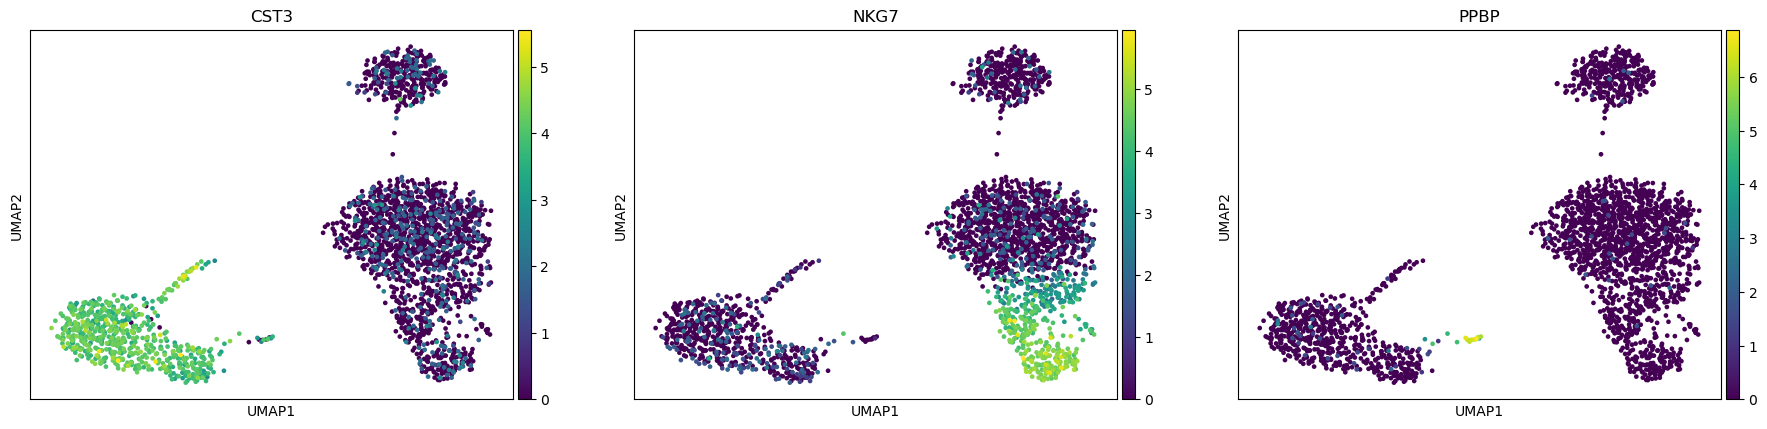

In [43]:
sc.pl.umap(adata, color=['CST3', 'NKG7', 'PPBP']) # creates 3 separate UMAP plots, each plot colored by expression of one gene

As we set the .raw attribute of adata, the previous plots showed the “raw” (normalized, logarithmized, but uncorrected) gene expression. You can also plot the scaled and corrected gene expression by explicitly stating that you don’t want to use .raw.

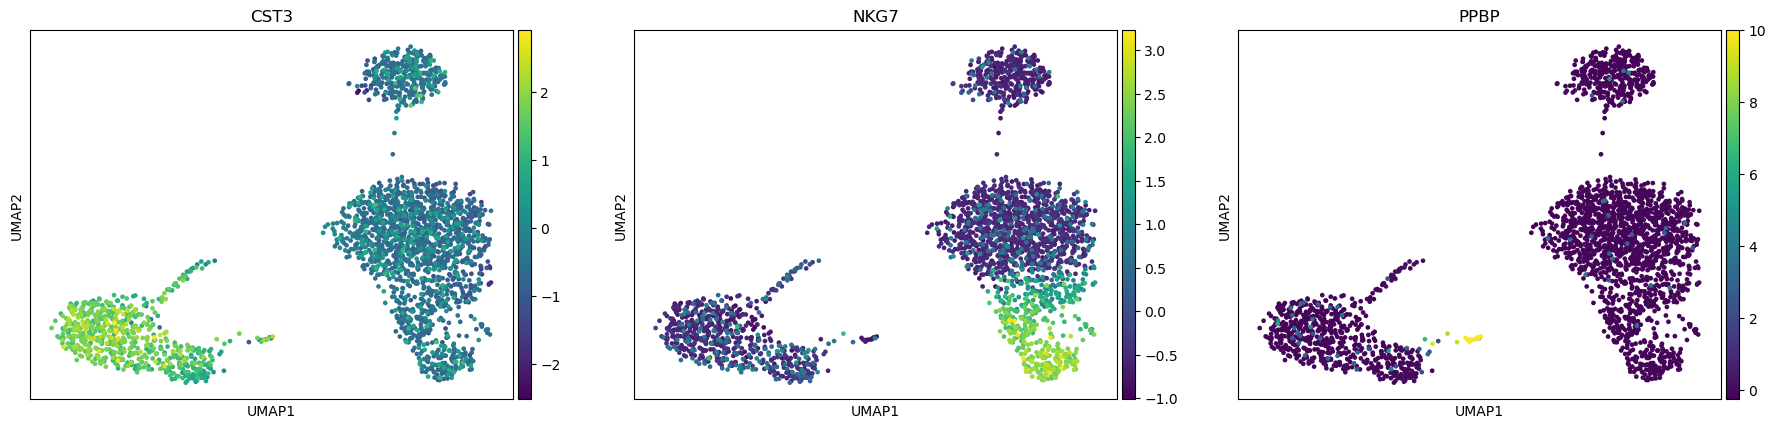

In [44]:
sc.pl.umap(adata, color=['CST3', 'NKG7', 'PPBP'], use_raw=False)

## Clustering the neighborhood graph

As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) by Traag et al. (2018). Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [45]:
!pip install leidenalg

Important parameter in leiden is resolution:
- low resolution → few big clusters
- high resolution → many small clusters

Clusters are:
- data-driven
- not automatically biological labels <br>
You still need to find marker genes and find out cell types.

In [46]:
sc.tl.leiden(adata, resolution=1.0, random_state=42) # running Leiden clustering. Resolution and random state is added for the reproducible results and to align with the tutorial otherwise I got different N of clusters

C:\Users\volko\AppData\Local\Temp\ipykernel_1324\3375919463.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0, random_state=42) # running Leiden clustering. Resolution and random state is added for the reproducible results and to align with the tutorial otherwise I got different N of clusters


Plot the clusters. 

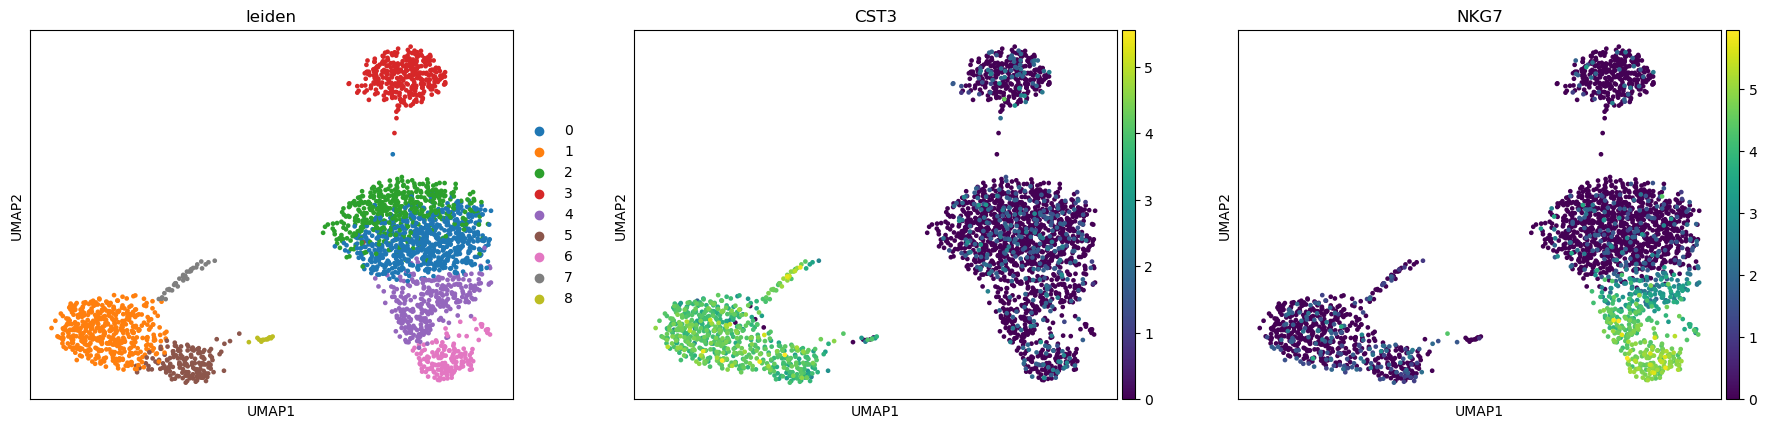

In [47]:
sc.pl.umap(adata, color=['leiden', 'CST3', 'NKG7'])

In short:  <br>
👉 neighbors → build graph <br>
👉 leiden → find groups <br>
👉 umap → visualize them <br>

In [48]:
adata.write(results_file)

## Finding marker genes

Let us compute a ranking for the highly differential genes in each cluster. For this, by default, the .raw attribute of AnnData is used in case it has been initialized before. The simplest and fastest method to do so is the t-test.

Howeer, t-test assumes normality (not always ideal for scRNA-seq).

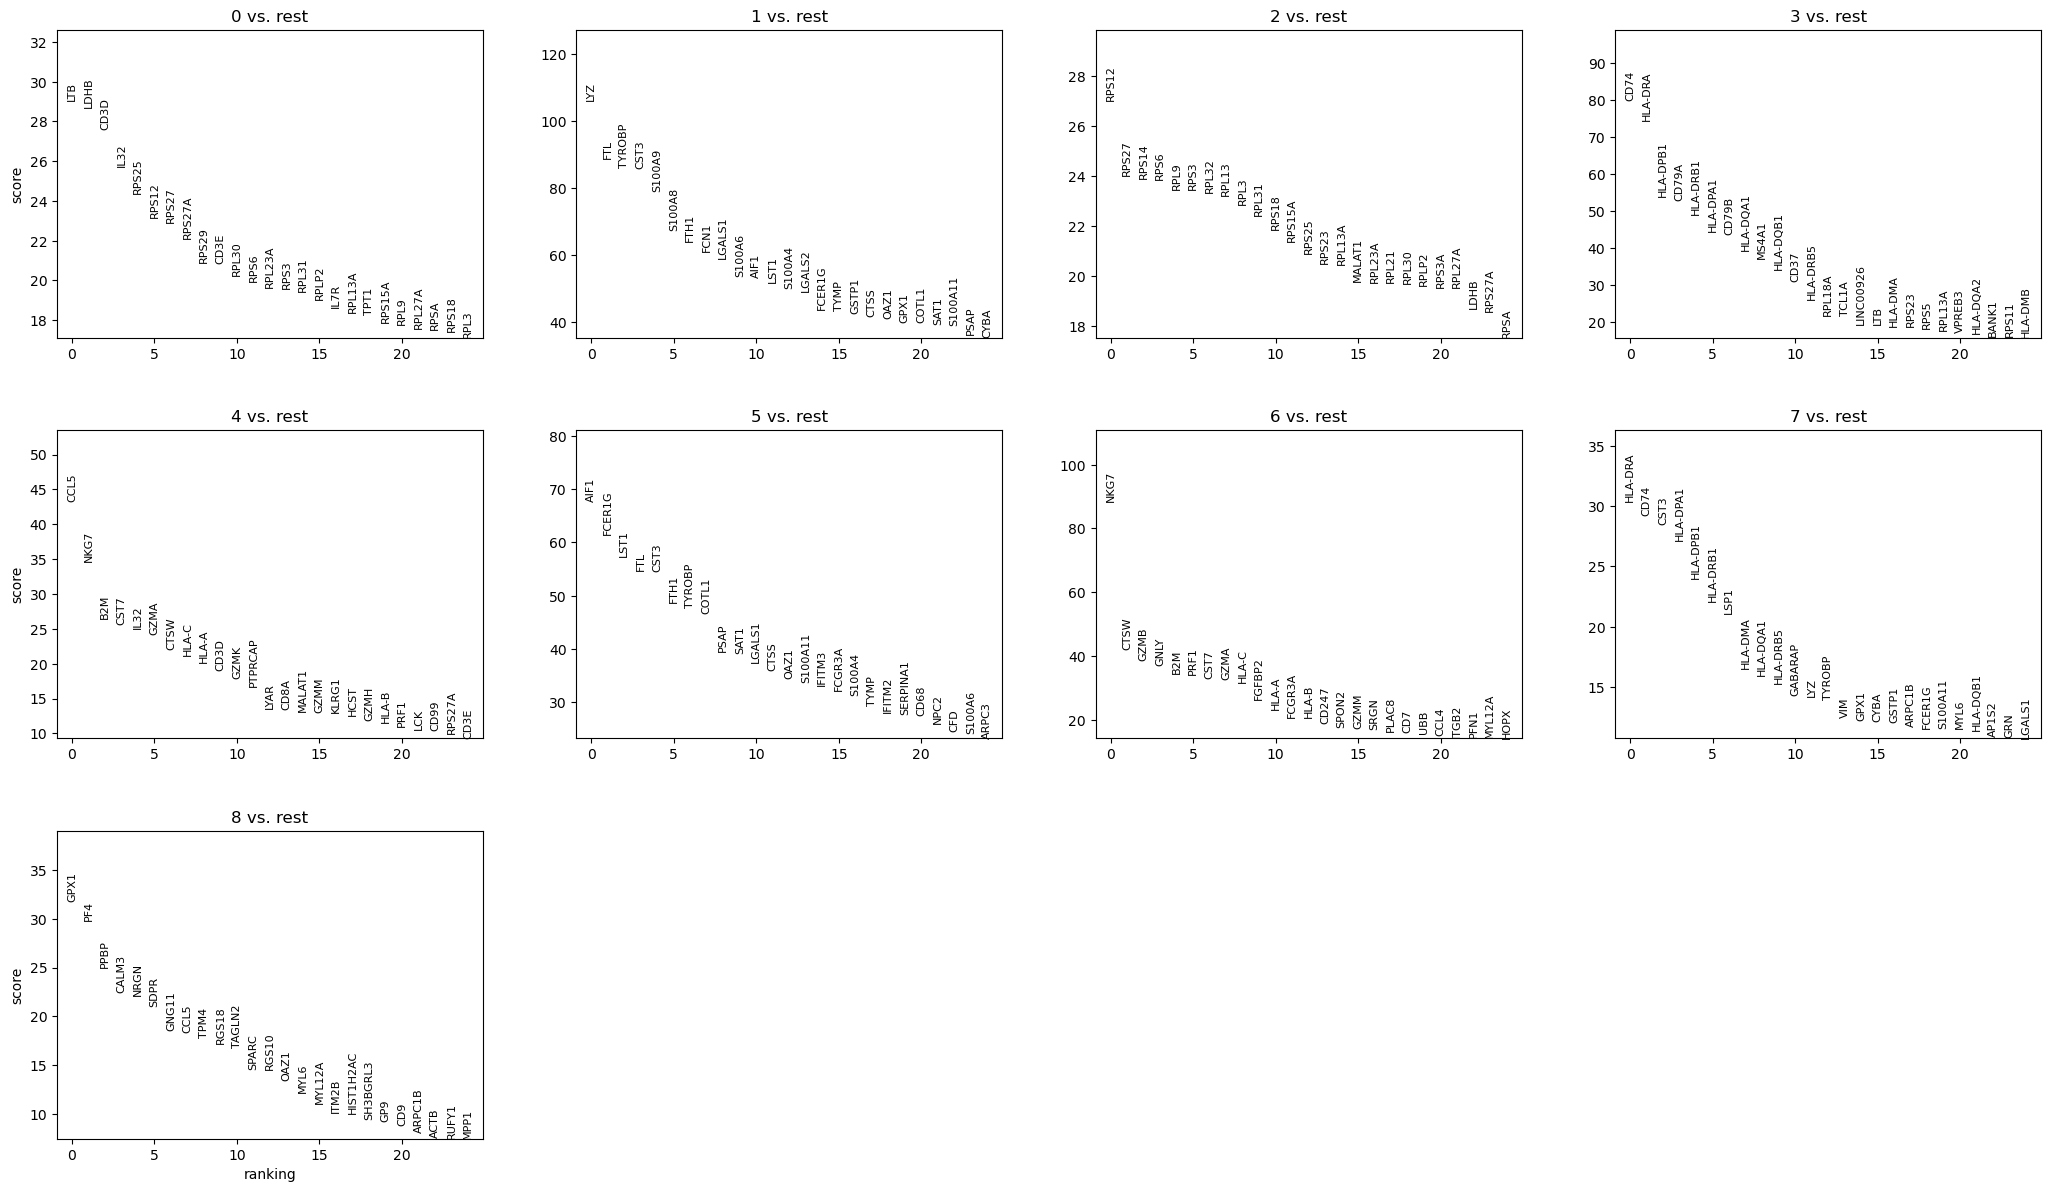

In [49]:
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test') # finds marker genes for each cluster, it gives a ranked list of genes that define each cluster
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False) # visualize, sharey=False each subplot has its own y-axis

The result of a Wilcoxon rank-sum (Mann-Whitney-U) test is very similar. We recommend using the latter in publications, see e.g., Sonison & Robinson (2018). You might also consider much more powerful differential testing packages like MAST, limma, DESeq2 and, for python, the recent diffxpy.

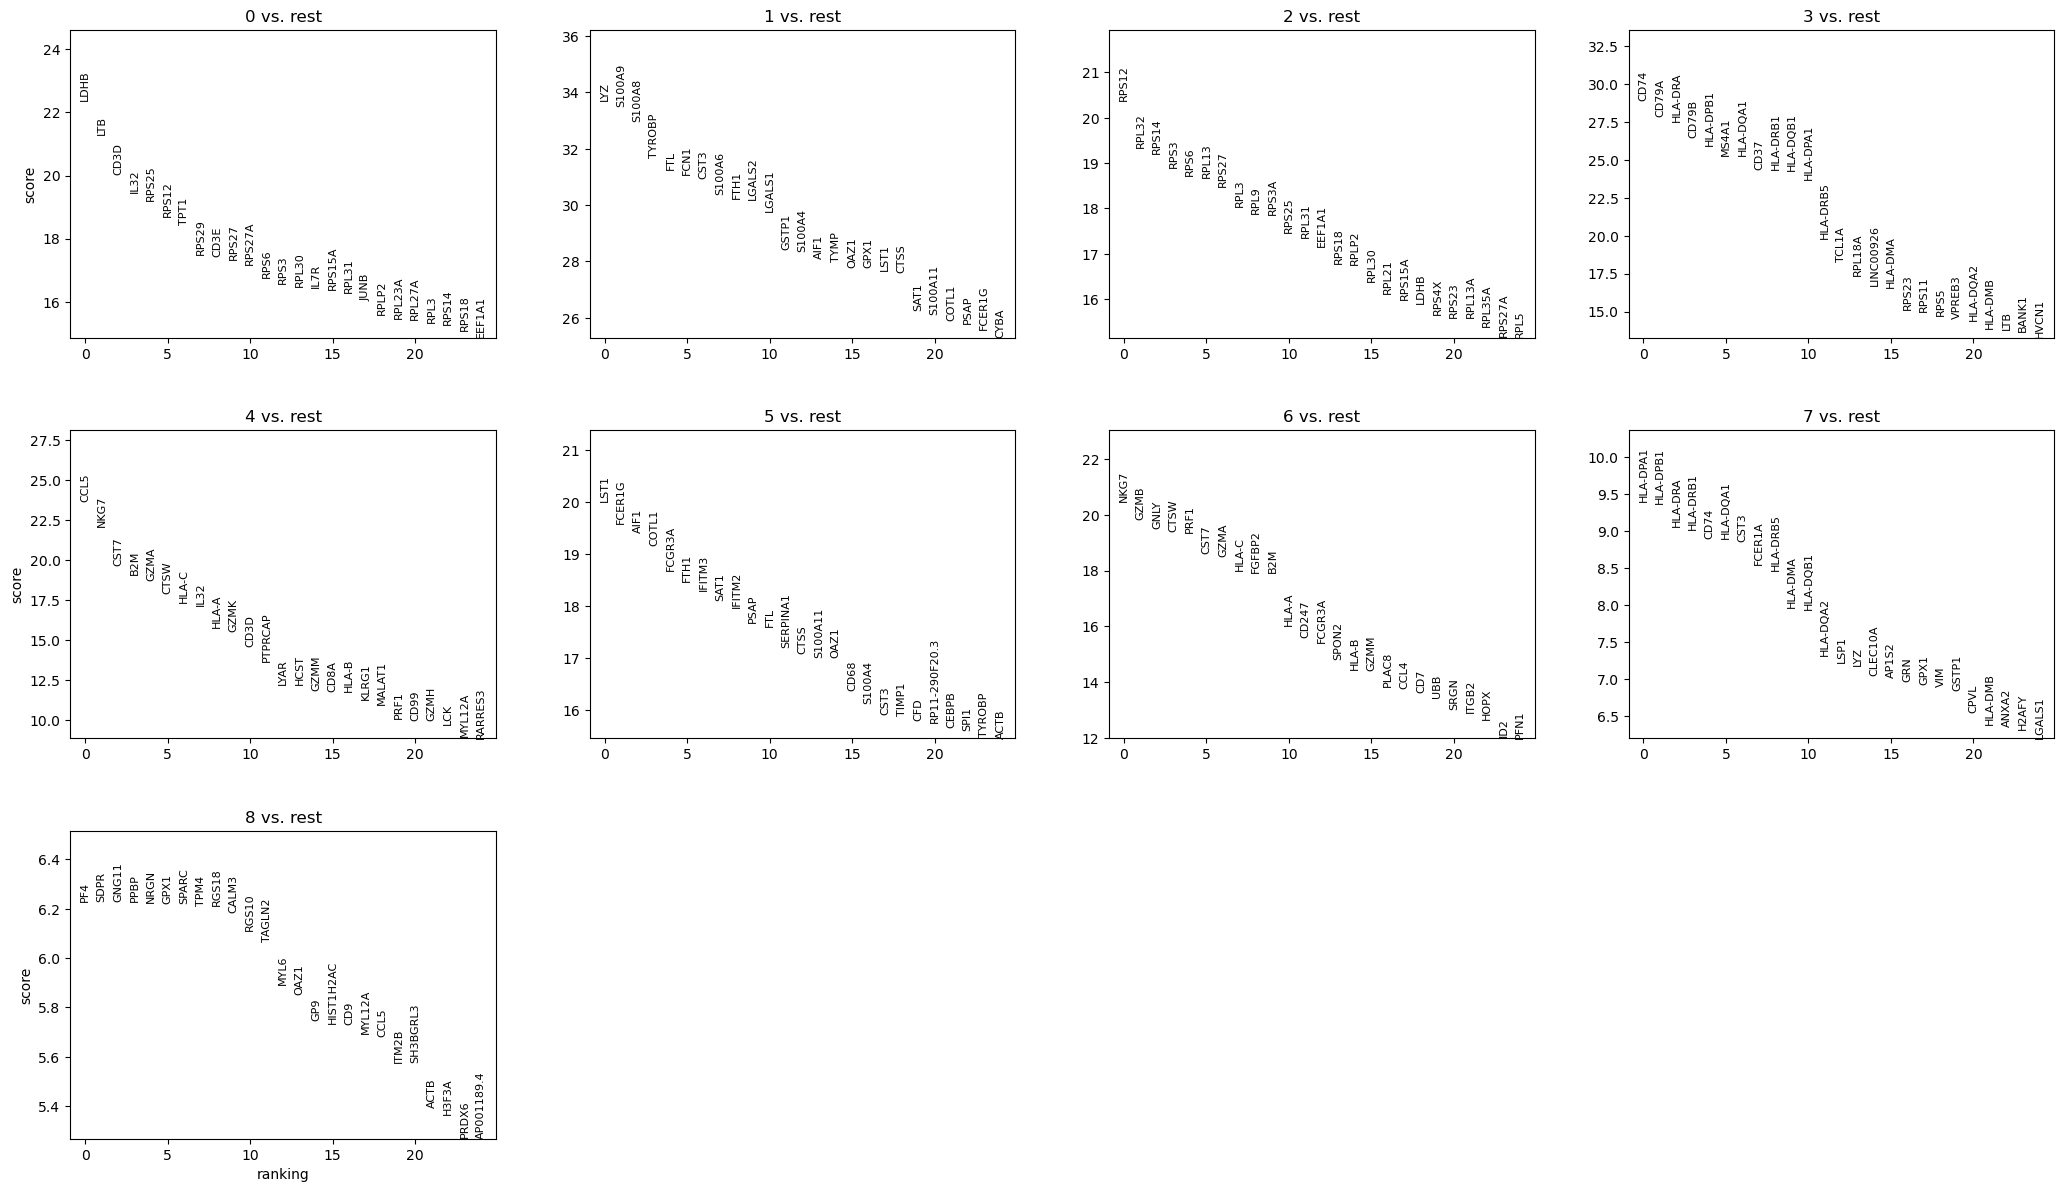

In [50]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [51]:
adata.write(results_file)
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

As an alternative, let us rank genes using logistic regression. For instance, this has been suggested by Natranos et al. (2018). The essential difference is that here, we use a multi-variate appraoch whereas conventional differential tests are uni-variate. Clark et al. (2014) has more details.

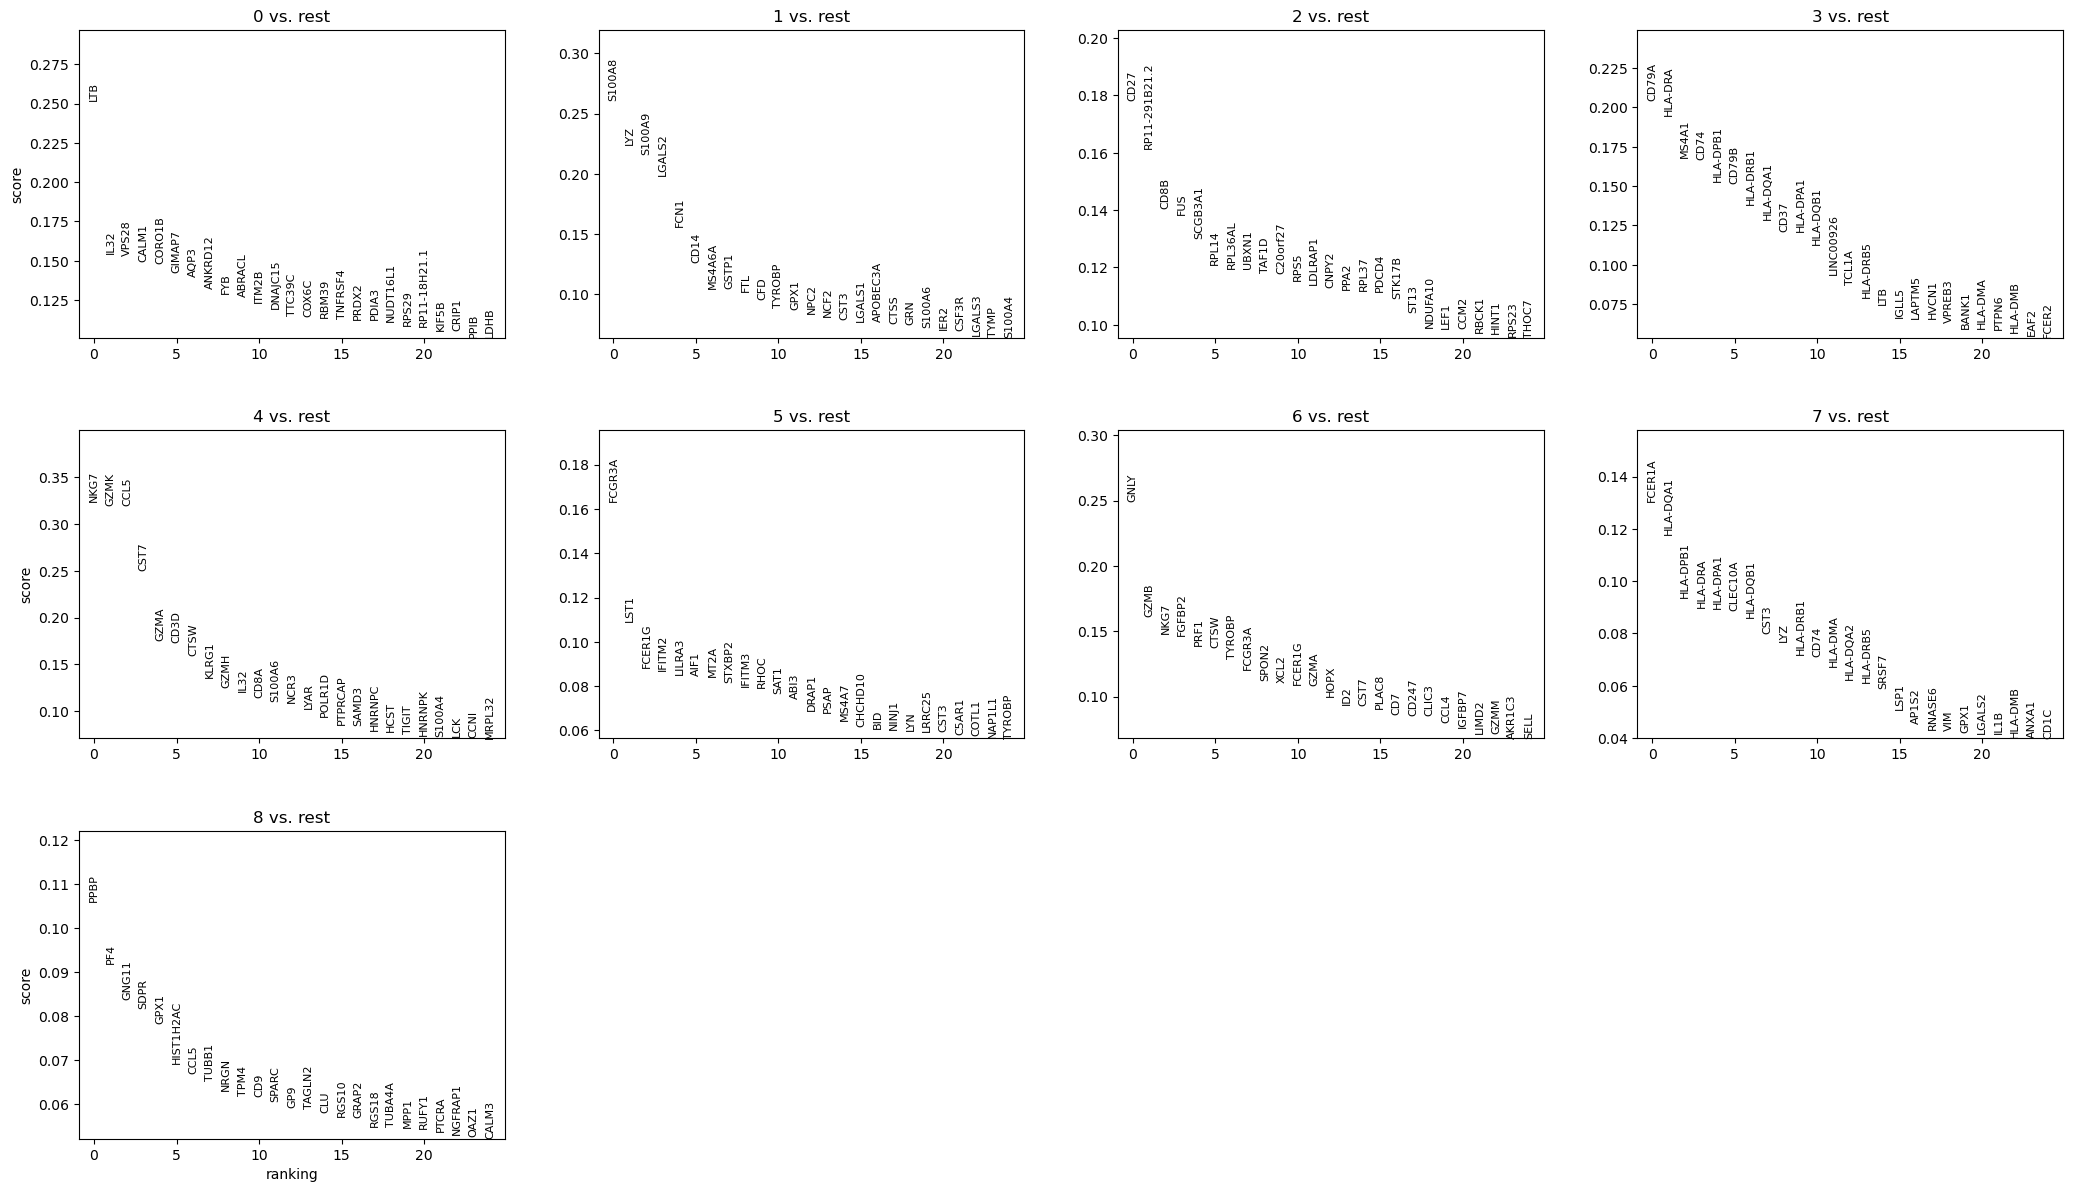

In [52]:
sc.tl.rank_genes_groups(adata, 'leiden', method='logreg')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

## Louvain Group Markers Cell Type

Main cell types and their markers:
0 CD4 T cells - IL7R <br> 
1 CD14+ Monocytes - CD14, LYZ  <br> 
2 B cells - MS4A1 <br>
3 CD8 T cells - CD8A  <br>
4 NK cells  - GNLY, NKG7 <br>
5 FCGR3A, MS4A7 FCGR3A+ Monocytes <br> 
6 FCER1A Dendritic Cells - CST3, FCER1A  <br>
7 Megakaryocytes/ Platelets - PPBP 

In [71]:
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ', 'CD14',
                'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',  
                'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP']

In [72]:
# Reload the object that has been save with the Wilcoxon Rank-Sum test result.
adata = sc.read(results_file)

In [76]:
# Show the 10 top ranked genes per cluster 0, 1, ..., 7 in a dataframe.
pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(10)

,0,1,2,3,4,5,6,7,8
0,LDHB,LYZ,RPS12,CD74,CCL5,LST1,NKG7,HLA-DPA1,PF4
1,LTB,S100A9,RPL32,CD79A,NKG7,FCER1G,GZMB,HLA-DPB1,SDPR
2,CD3D,S100A8,RPS14,HLA-DRA,CST7,AIF1,GNLY,HLA-DRA,GNG11
3,IL32,TYROBP,RPS3,CD79B,B2M,COTL1,CTSW,HLA-DRB1,PPBP
4,RPS25,FTL,RPS6,HLA-DPB1,GZMA,FCGR3A,PRF1,CD74,NRGN
5,RPS12,FCN1,RPL13,MS4A1,CTSW,FTH1,CST7,HLA-DQA1,GPX1
6,TPT1,CST3,RPS27,HLA-DQA1,HLA-C,IFITM3,GZMA,CST3,SPARC
7,RPS29,S100A6,RPL3,CD37,IL32,SAT1,HLA-C,FCER1A,TPM4
8,CD3E,FTH1,RPL9,HLA-DRB1,HLA-A,IFITM2,FGFBP2,HLA-DRB5,RGS18
9,RPS27,LGALS2,RPS3A,HLA-DQB1,GZMK,PSAP,B2M,HLA-DMA,CALM3


In [78]:
# Get a table with the scores and groups.
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(10)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p,8_n,8_p
0,LDHB,9.027304e-111,LYZ,7.634876e-249,RPS12,3.315438e-92,CD74,2.487145e-183,CCL5,6.165318e-124,LST1,3.817912e-89,NKG7,3.591782e-93,HLA-DPA1,5.422417e-21,PF4,4.722886e-10
1,LTB,1.003772e-100,S100A9,4.621214e-246,RPL32,2.166925e-83,CD79A,1.679730e-170,NKG7,2.045524e-108,FCER1G,1.922876e-85,GZMB,2.033412e-87,HLA-DPB1,7.591860e-21,SDPR,4.733899e-10
2,CD3D,3.422569e-89,S100A8,1.622835e-238,RPS14,3.363592e-82,HLA-DRA,6.935111e-167,CST7,5.994025e-86,AIF1,4.874658e-84,GNLY,8.130223e-85,HLA-DRA,1.306768e-19,GNG11,4.733899e-10
3,IL32,1.849122e-84,TYROBP,2.960765e-220,RPS3,1.210239e-79,CD79B,2.569135e-154,B2M,1.727600e-81,COTL1,6.803289e-82,CTSW,6.944632e-84,HLA-DRB1,1.865104e-19,PPBP,4.744938e-10
4,RPS25,3.876244e-82,FTL,2.479195e-214,RPS6,3.830129e-78,HLA-DPB1,3.577195e-148,GZMA,3.193694e-78,FCGR3A,5.798309e-78,PRF1,1.621421e-83,CD74,5.853161e-19,NRGN,4.800511e-10
5,RPS12,5.959171e-78,FCN1,5.765884e-212,RPL13,6.140716e-78,MS4A1,6.299036e-141,CTSW,6.677336e-72,FTH1,3.369454e-76,CST7,4.006448e-77,HLA-DQA1,5.882263e-19,GPX1,4.947990e-10
6,TPT1,6.726527e-76,CST3,4.101035e-210,RPS27,2.553979e-76,HLA-DQA1,8.015932e-141,HLA-C,2.776913e-67,IFITM3,7.100291e-75,GZMA,2.736925e-76,CST3,8.003226e-19,SPARC,4.947990e-10
7,RPS29,1.979901e-68,S100A6,1.893868e-202,RPL3,1.085482e-72,CD37,2.427950e-131,IL32,5.343607e-66,SAT1,2.340430e-73,HLA-C,1.541370e-72,FCER1A,1.207857e-17,TPM4,5.159513e-10
8,CD3E,5.059054e-68,FTH1,7.852573e-201,RPL9,1.760796e-71,HLA-DRB1,4.950220e-131,HLA-A,3.326823e-56,IFITM2,3.179414e-72,FGFBP2,8.320724e-72,HLA-DRB5,2.607032e-17,RGS18,5.195614e-10
9,RPS27,2.199691e-67,LGALS2,2.592725e-200,RPS3A,2.186456e-71,HLA-DQB1,1.686171e-130,GZMK,2.701465e-54,PSAP,5.755481e-70,B2M,9.051851e-72,HLA-DMA,1.692312e-15,CALM3,6.197000e-10


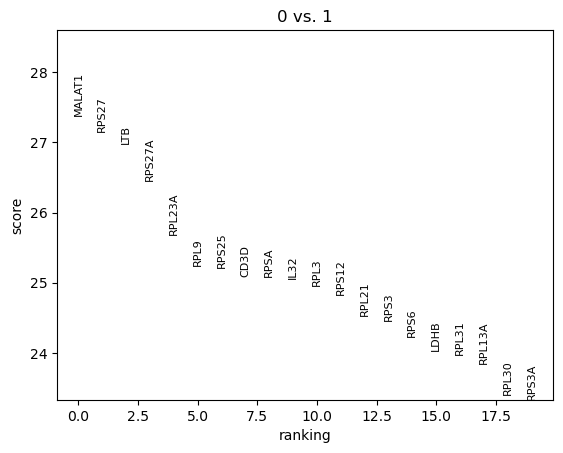

In [79]:
sc.tl.rank_genes_groups(adata, 'leiden', groups=['0'], reference='1', method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=['0'], n_genes=20)

This violin plot shows how strongly and specifically the top marker genes for a cluster are expressed across all clusters, helping to validate whether they are good markers.

C:\Users\volko\anaconda3\lib\site-packages\scanpy\plotting\_tools\__init__.py:1320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


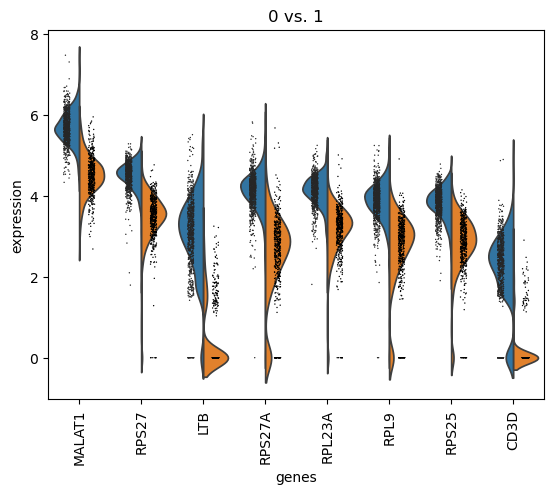

In [80]:
# If we want a more detailed view for a certain group, use sc.pl.rank_genes_groups_violin.
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)

In [81]:
# Reload the object with the computed differential expression (i.e. DE via a comparison with the rest of the groups):


adata = sc.read(results_file)

C:\Users\volko\anaconda3\lib\site-packages\scanpy\plotting\_tools\__init__.py:1320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


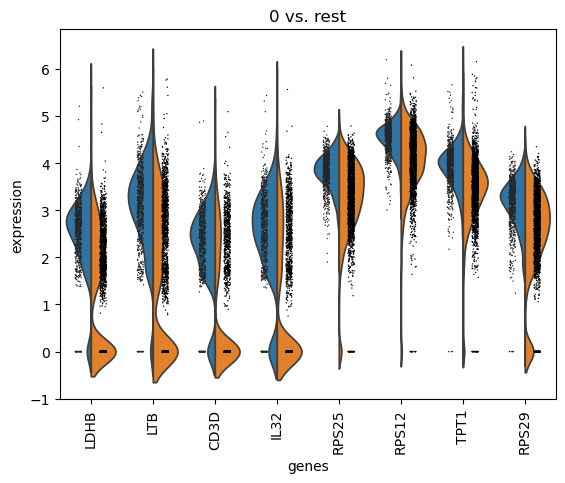

In [82]:
sc.pl.rank_genes_groups_violin(adata, groups='0', n_genes=8)

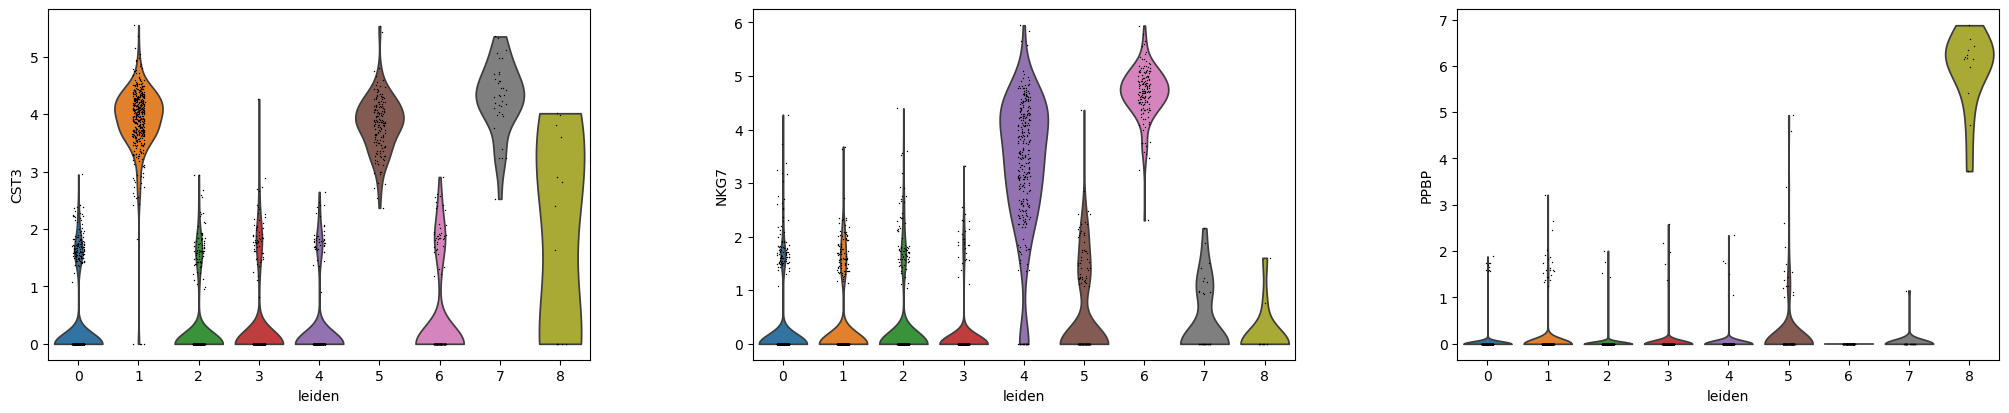

In [83]:
sc.pl.violin(adata, ['CST3', 'NKG7', 'PPBP'], groupby='leiden')

In [84]:
print(adata.obs['leiden'].nunique() )
adata.obs['leiden'].value_counts() # to check if any cluster is too small

9


leiden
0    704
1    478
2    455
3    341
4    294
5    159
6    158
7     36
8     13
Name: count, dtype: int64

In [85]:
new_cluster_names = [
    'CD4 T', 'CD14 Monocytes',
    'B', 'CD8 T', 
    'NK', 'FCGR3A Monocytes',
    'Dendritic', 'Megakaryocytes']
print(len(new_cluster_names))
if 0: # get the different number of clusters then in tutorial

    adata.rename_categories('leiden', new_cluster_names)

8


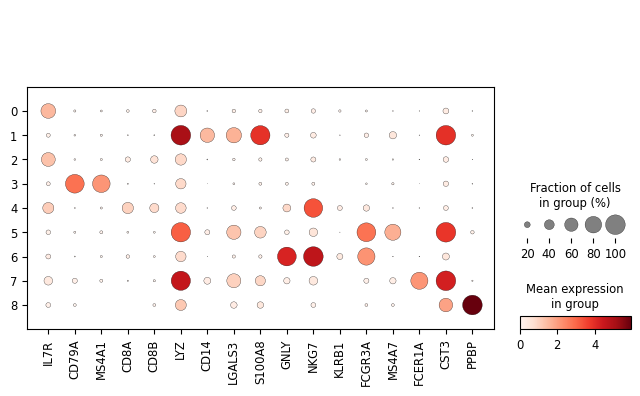

In [86]:
# Now that we annotated the cell types, let us visualize the marker genes.

sc.pl.dotplot(adata, marker_genes, groupby='leiden');

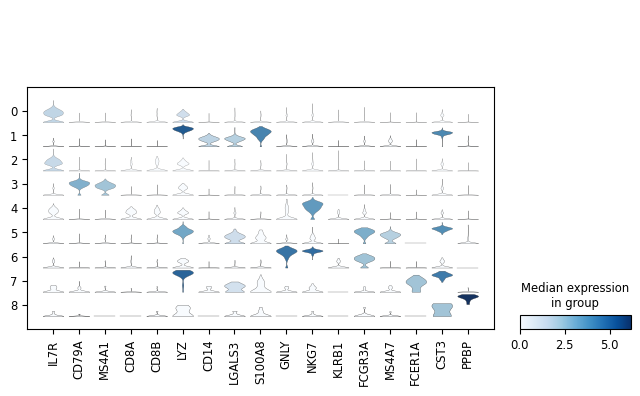

In [89]:
# There is also a very compact violin plot.
sc.pl.stacked_violin(adata, marker_genes, groupby='leiden')

In [90]:
# During the course of this analysis, the AnnData accumlated the following annotations.
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [91]:
adata.write(results_file, compression='gzip')  # `compression='gzip'` saves disk space, but slows down writing and subsequent reading

If you want to share this file with people who merely want to use it for visualization, a simple way to reduce the file size is by removing the dense scaled and corrected data matrix. The file still contains the raw data used in the visualizations in adata.raw.

In [ ]:
adata.raw.to_adata().write('pbmc3k_withoutX.h5ad')

If you want to export to "csv", you have the following options:

In [92]:
# Export single fields of the annotation of observations
# adata.obs[['n_counts', 'louvain_groups']].to_csv(
#     './write/pbmc3k_corrected_louvain_groups.csv')

# Export single columns of the multidimensional annotation
# adata.obsm.to_df()[['X_pca1', 'X_pca2']].to_csv(
#     './write/pbmc3k_corrected_X_pca.csv')

# Or export everything except the data using `.write_csvs`.
# Set `skip_data=False` if you also want to export the data.
# adata.write_csvs(results_file[:-5], )

Summary of the cell types:
1. CD4 T cells <br>
Marker: IL7R<br>
Function: helper T cells<br>
2. CD8 T cells<br>
Markers: CD8A, CD8B<br>
Function: cytotoxic T cells<br>
3. B cells<br>
Markers: MS4A1, CD79A<br>
Function: antibody production<br>
4. NK cells<br>
Markers: NKG7, GNLY<br>
Function: innate immune killing<br>
5. CD14 Monocytes (classical)<br>
Markers: CD14, LYZ<br>
Function: phagocytosis, inflammation<br>
6. FCGR3A Monocytes (non-classical)<br>
Markers: FCGR3A, MS4A7<br>
Function: patrolling monocytes<br>
7. Dendritic cells<br>
Markers: FCER1A, CST3<br>
Function: antigen presentation<br>
8. Megakaryocytes / Platelets<br>
Marker: PPBP<br>
Function: clotting